In [22]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')  # or sys.path.insert(0, '..')
import plot_settings
plot_settings.apply()

SOC: [1.00000000e+00 9.99722222e-01 9.99444444e-01 ... 8.33333333e-04
 5.55555555e-04 2.77777778e-04]


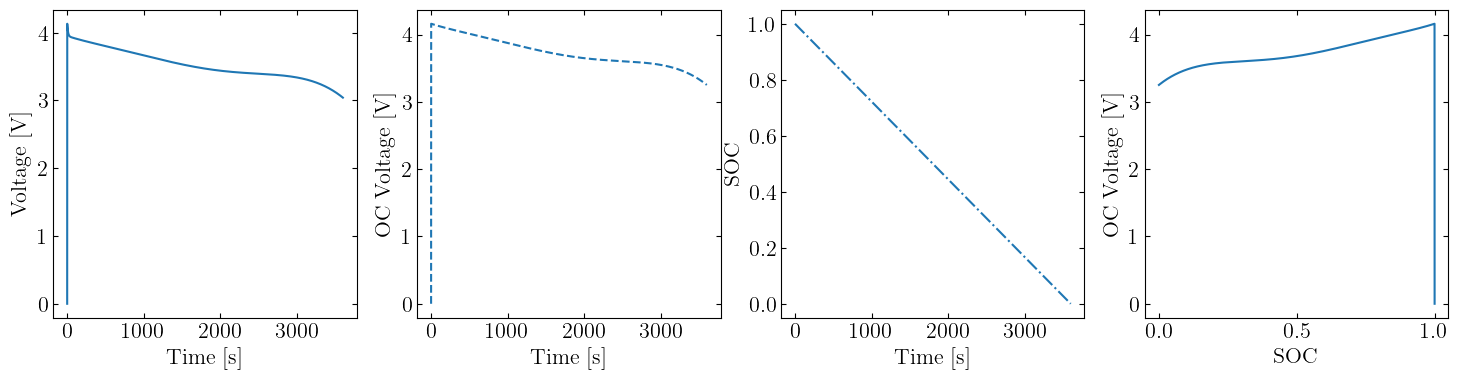

In [78]:
# Parameters
params = dict(
    Q=2*3600, # Capacity As    1Ah = 3600 As
    R0=0.005, # Ohm
    R1=0.1, # Ohm
    C1=100, # F
    dt=1, # time step in seconds
    I=2 # Current in A
)
params['a'] = np.exp(-params['dt'] / (params['R1'] * params['C1'])) # Time constant for the RC circuit

# Polynomial function for OC voltage vs SOC (example coefficients)
def V_soc_poly(soc):
    coeffs = [3.25, 3.29, -11.96, 19.33, -8.90, -4.65, 3.80]
    return np.sum([soc**i * coeff for i, coeff in enumerate(coeffs)])


def step(state, I, p):
    soc, U1 = state

    soc_new = soc - (I * p['dt'] / p['Q'])
    U1_new = p['a']*U1 + p['R1']*(1 - p['a'])*I
    V_soc_new = V_soc_poly(soc_new)
    V = V_soc_new - I*p['R0'] - U1_new
    return (soc_new, U1_new), V, V_soc_new


def simulation(time, I, p):
    soc = np.zeros(time.size)
    U1 = np.zeros(time.size)
    V = np.zeros(time.size)
    V_soc = np.zeros(time.size)

    soc[0] = 1 # Initial SOC (fully charged)
    U1[0] = 0 # Initial voltage across C1
    state = (soc[0], U1[0])

    for t in range(1, len(time)):
        state, V[t], V_soc[t] = step(state, I, p)
        soc[t], U1[t] = state

    return soc, U1, V, V_soc


time = np.arange(0, 3600, params['dt']) # 1 hour of simulation
soc, U1, V, V_soc = simulation(time, params['I'], params)

# Plotting
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(18, 4))
ax1.plot(time, V, label='Terminal Voltage [V]')
ax1.set_ylabel('Voltage [V]')
ax1.set_xlabel('Time [s]')
ax2.plot(time, V_soc, label='OC Voltage [V]', linestyle='--')
ax2.set_ylabel('OC Voltage [V]')
ax2.set_xlabel('Time [s]')
ax3.plot(time, soc, label='State of Charge (SOC)', linestyle='-.')
ax3.set_ylabel('SOC')
ax3.set_xlabel('Time [s]')
ax4.plot(soc, V_soc, label='OC Voltage vs SOC')
ax4.set_ylabel('OC Voltage [V]')
ax4.set_xlabel('SOC')

print(f"SOC: {soc}")

Text(0.5, 0, 'SOC')

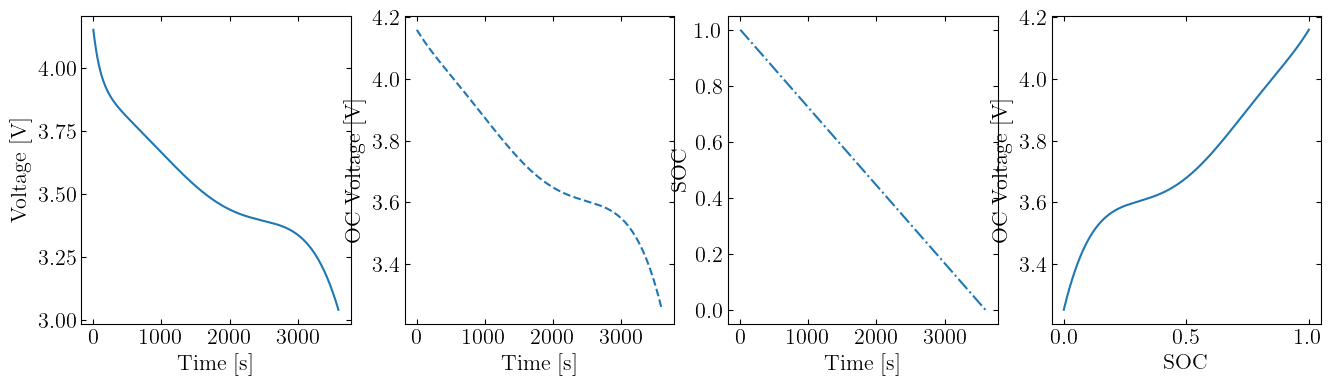

In [79]:
# Parameters
Q = 2*3600 # Capacity As    1Ah = 3600 As
R0 = 0.005 # Ohm
R1 = 0.1 # Ohm
C1 = 1000 # F
dt = 1 # time step in seconds
I = 2 # Current in A

time = np.arange(0, 3600, dt) # 1 hour of simulation
a = np.exp(-dt / (R1 * C1)) # Time constant for the RC circuit

# Polynomial function for OC voltage vs SOC (example coefficients)
def V_soc_poly(soc):
    coeffs = [3.25, 3.29, -11.96, 19.33, -8.90, -4.65, 3.80]
    return np.sum([soc**i * coeff for i, coeff in enumerate(coeffs)])

V = np.zeros(time.size) # Voltage
U1 = np.zeros(time.size) # Voltage across C1
soc = np.zeros(time.size) # State of Charge
V_soc = np.zeros(time.size) # OC voltage

# Initialize arrays
U1[0] = 0 # Initial voltage across C1   
soc[0] = 1 # Initial SOC (fully charged)
V_soc[0] = V_soc_poly(soc[0]) # Initial OC voltage
V[0] = V_soc[0] - I*R0 - U1[0] # Initial voltage in V

def evolve(soc, V_soc, U1, V):
    soc[t] = soc[t-1] - (I * dt / Q) # Update SOC
    V_soc[t] = V_soc_poly(soc[t])
    U1[t] = a*U1[t-1] + R1*(1 - a)*I # Voltage across R1
    V[t] = V_soc[t] - I*R0 - U1[t] # Terminal voltage
    return soc, V_soc, U1, V

# Simulation loop
for t in range(1, len(time)):
    soc, V_soc, U1, V = evolve(soc, V_soc, U1, V)

# Plotting
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4))
ax1.plot(time, V, label='Terminal Voltage [V]')
ax1.set_ylabel('Voltage [V]')
ax1.set_xlabel('Time [s]')
ax2.plot(time, V_soc, label='OC Voltage [V]', linestyle='--')
ax2.set_ylabel('OC Voltage [V]')
ax2.set_xlabel('Time [s]')
ax3.plot(time, soc, label='State of Charge (SOC)', linestyle='-.')
ax3.set_ylabel('SOC')
ax3.set_xlabel('Time [s]')
ax4.plot(soc, V_soc, label='OC Voltage vs SOC')
ax4.set_ylabel('OC Voltage [V]')
ax4.set_xlabel('SOC')